In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

1. Preparação e Merge de Dados
- Carregue os arquivos 03.BaseDPEvolucaoMensalCisp.csv e 08.DP.csv.
- Faça um merge entre as bases utilizando a chave correspondente (cisp na
base mensal e codDP na base de delegacias).
- Isole e trate possíveis valores nulos ou inconsistentes nas colunas-alvo:
roubo_celular e roubo_transeunte

In [2]:
# Parte 1. Preparação e Merge de dados

try:
    df_ocorrencias = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv',encoding='iso-8859-1',sep=";")
    df_dp = pd.read_csv('08.DP.csv', sep=",")
    df_merge = df_ocorrencias.merge(df_dp, left_on='cisp', right_on='codDP', how='left')

    df_selecao = df_merge[['cisp', 'nome', 'roubo_transeunte', 'roubo_celular', 'ano', 'regiao', 'mes']].copy()
    df_selecao['nome'] = df_selecao['nome'].fillna('Delegacia Não Identificada')
    df_selecao['roubo_celular'] = df_selecao['roubo_celular'].fillna(0)
    df_selecao['roubo_transeunte'] = df_selecao['roubo_transeunte'].fillna(0)

    df_crimes_agrupado = df_selecao.groupby(['cisp', 'nome'])[['roubo_transeunte', 'roubo_celular']].sum().reset_index()

except Exception as e:
    print(f'Erro ao importar dados: {e}')


In [3]:
df_selecao

,cisp,nome,roubo_transeunte,roubo_celular,ano,regiao,mes
0,1,001ª DP - Praça da República,26,32,2003,Capital,1
1,4,004ª DP - Praça da República,25,14,2003,Capital,1
2,5,005ª DP - Mem de Sá,26,34,2003,Capital,1
3,6,006ª DP - Cidade Nova,14,20,2003,Capital,1
4,7,007ª DP - Santa Teresa,4,1,2003,Capital,1
...,...,...,...,...,...,...,...
34843,159,159ª DP - Cachoeira de Macacu,1,0,2024,Interior,7
34844,165,165ª DP - Mangaratiba,0,0,2024,Interior,7
34845,166,166ª DP - Angra dos Reis,2,1,2024,Interior,7
34846,167,167ª DP - Paraty,2,2,2024,Interior,7


In [4]:
df_crimes_agrupado

,cisp,nome,roubo_transeunte,roubo_celular
0,1,001ª DP - Praça da República,15243,3989
1,4,004ª DP - Praça da República,18122,4332
2,5,005ª DP - Mem de Sá,29650,6912
3,6,006ª DP - Cidade Nova,11883,2578
4,7,007ª DP - Santa Teresa,4691,623
...,...,...,...,...
133,159,159ª DP - Cachoeira de Macacu,480,72
134,165,165ª DP - Mangaratiba,540,182
135,166,166ª DP - Angra dos Reis,2005,559
136,167,167ª DP - Paraty,380,82


2. Diagnóstico Estatístico
Para as variáveis roubo_celular e roubo_transeunte, calcule:
- Medidas de Tendência Central: Média, Mediana e Moda.
- Dispersão: Variância, Desvio Padrão e Coeficiente de Variação (CV).
- Posição e Limites: Mínimo, Máximo, Amplitude, Quartis (Q1, Q2/Mediana,
Q3) e os Limites Inferior e Superior utilizando a regra do IQR (Intervalo
Interquartil).
- Formato da Distribuição: Assimetria (Skewness) e Curtose (Kurtosis).
- Análise de Deslocamento: Calcule o Delta (diferença) entre a Média e a
Mediana. ○ Explique, de forma didática para o negócio, o que esse Delta somado
à métrica de Assimetria revela sobre o comportamento mensal de
roubos (ex: se os dados são inflados por meses extremamente
violentos).


In [5]:
# medidas de tendência central
media_cel = df_selecao['roubo_celular'].mean()
mediana_cel = df_selecao['roubo_celular'].median()

# medidas de disperção 
desvio_cel = np.std(df_selecao['roubo_celular'])
variancia_cel = np.var(df_selecao['roubo_celular'])
cv_cel = desvio_cel/media_cel

# medidas de posição
amplitude_cel = np.max(df_selecao['roubo_celular']) - np.min(df_selecao['roubo_celular'])
q1_cel = df_selecao['roubo_celular'].quantile(0.25)
q3_cel = df_selecao['roubo_celular'].quantile(0.75)
iqr_cel = q3_cel - q1_cel
limite_sup_cel = q3_cel + 1.5 * iqr_cel
limite_inf_cel = q1_cel - 1.5 * iqr_cel

# medidas de forma
assimetria_cel = df_selecao['roubo_celular'].skew()
kurt_cel = df_selecao['roubo_celular'].kurtosis()

delta_media_mediana_cel = media_cel / mediana_cel


print(f'Média roubos: {media_cel:,.2f}')
print(f'Mediana roubos: {mediana_cel:,.2f}')
print(f'Diferença entre média e mediana: {delta_media_mediana_cel:,.2f}')
print(f"Mín: {np.min(df_selecao['roubo_celular']):,.2f}")
print(f'Limite inferior: {limite_inf_cel:,.2f}')
print(f'Q1: {q1_cel:,.2f}')
print(f'Q3: {q3_cel:,.2f}')
print(f"Máx: {np.max(df_selecao['roubo_celular']):,.2f}")
print(f'Limite Superior: {limite_sup_cel:,.2f}')
print(f'Desvio padrão: {desvio_cel:,.2f}')
print(f'Coeficiente de variação: {cv_cel:,.2f}')
print(f'Assimetria: {assimetria_cel:,.2f}')
print(f'Curtose: {kurt_cel:,.2f}')

Média roubos: 7.97
Mediana roubos: 2.00
Diferença entre média e mediana: 3.98
Mín: 0.00
Limite inferior: -16.50
Q1: 0.00
Q3: 11.00
Máx: 205.00
Limite Superior: 27.50
Desvio padrão: 13.52
Coeficiente de variação: 1.70
Assimetria: 3.37
Curtose: 18.80


Explique, de forma didática para o negócio, o que esse Delta somado
à métrica de Assimetria revela sobre o comportamento mensal de
roubos de celular (ex: se os dados são inflados por meses extremamente violentos).

- R: O Delta nos revela um desequilíbrio crítico, no qual a média de roubos é 4 vezes maior que a mediana. Do ponto de vista de negócios para a Seguradora, isso significa que usar a "Média Estadual" para precificar o seguro de celular vai gerar prejuízo. A forte assimetria prova que os dados são inflados por regiões específicas com muitos sinistros, e não por um aumento geral no Estado. Enquanto a maioria das regiões tem uma mediana segura de apenas 2 casos, houve região com 205 registros de roubo em um único mês. Diante disso, a recomendação para a Diretoria é que a precificação do prêmio (mensalidade do seguro) não seja estadual, mas sim regionalizada por CEP. Regiões na mediana podem ter seguros mais baratos e atrativos, enquanto os CEPs que puxam a assimetria precisam sofrer um forte reajuste de risco para proteger as margens de lucro da empresa. 

In [6]:
# medidas de tendência central
media_trans = df_selecao['roubo_transeunte'].mean()
mediana_trans = df_selecao['roubo_transeunte'].median()

# medidas de disperção 
desvio_trans = np.std(df_selecao['roubo_transeunte'])
variancia_trans = np.var(df_selecao['roubo_transeunte'])
cv_trans = desvio_trans/media_trans

# medidas de posição
amplitude_trans = np.max(df_selecao['roubo_transeunte']) - np.min(df_selecao['roubo_transeunte'])
q1_trans = df_selecao['roubo_transeunte'].quantile(0.25)
q3_trans = df_selecao['roubo_transeunte'].quantile(0.75)
iqr_trans = q3_trans - q1_trans
limite_sup_trans = q3_trans + 1.5 * iqr_trans
limite_inf_trans = q1_trans - 1.5 * iqr_trans

# medidas de forma
assimetria_trans = df_selecao['roubo_transeunte'].skew()
kurt_trans = df_selecao['roubo_transeunte'].kurtosis()

delta_media_mediana_trans = media_trans / mediana_trans


print(f'Média roubos: {media_trans:,.2f}')
print(f'Mediana roubos: {mediana_trans:,.2f}')
print(f'Diferença entre média e mediana: {delta_media_mediana_trans:,.2f}')
print(f"Mín: {np.min(df_selecao['roubo_transeunte']):,.2f}")
print(f'Limite inferior: {limite_inf_trans:,.2f}')
print(f'Q1: {q1_trans:,.2f}')
print(f'Q3: {q3_trans:,.2f}')
print(f"Máx: {np.max(df_selecao['roubo_transeunte']):,.2f}")
print(f'Limite Superior: {limite_sup_trans:,.2f}')
print(f'Desvio padrão: {desvio_trans:,.2f}')
print(f'Coeficiente de variação: {cv_trans:,.2f}')
print(f'Assimetria: {assimetria_trans:,.2f}')
print(f'Curtose: {kurt_trans:,.2f}')

Média roubos: 34.94
Mediana roubos: 11.00
Diferença entre média e mediana: 3.18
Mín: 0.00
Limite inferior: -79.50
Q1: 0.00
Q3: 53.00
Máx: 504.00
Limite Superior: 132.50
Desvio padrão: 51.01
Coeficiente de variação: 1.46
Assimetria: 2.37
Curtose: 7.79


Explique, de forma didática para o negócio, o que esse Delta somado
à métrica de Assimetria revela sobre o comportamento mensal de
roubos a pedestres em via pública (ex: se os dados são inflados por meses extremamente violentos).

- R: Assim como no roubo de celulares, o crime de roubo contra pedestres apresenta uma média financeiramente "mentirosa" para a seguradora (mais de 3 vezes maior que a mediana). A assimetria de 2,37 alerta o comitê de risco de que os sinistros de proteção pessoal estão concentrados em territórios específicos. Usar a média para avaliar o risco da carteira de clientes superestima o perigo na maioria das regiões (que têm apenas 11 roubos/mês) — o que nos faria cobrar um seguro muito caro e perder vendas para a concorrência, e também subestima o risco em zonas extremas (com picos de até 504 roubos/mês), onde a empresa fatalmente pagaria mais indenizações do que arrecada.

3. Identificação de Anomalias (Outliers)
- A partir dos Limites Superiores calculados na etapa anterior, crie um array
(utilizando Numpy) isolando os registros que são estatisticamente
considerados Outliers.
- Identifique a Delegacia (nome da DP) que concentra o maior número de
meses classificados como outliers absolutos para roubo_celular.

In [7]:
outliers_cel = df_selecao[df_selecao['roubo_celular'] > limite_sup_cel][['nome', 'roubo_celular']]

array_outliers_cel = np.array(outliers_cel)

print(f"Total de registros considerados outliers: \n{(array_outliers_cel)}")

Total de registros considerados outliers: 
[['001ª DP - Praça da República' 32]
 ['005ª DP - Mem de Sá' 34]
 ['021ª DP - Bonsucesso' 31]
 ...
 ['059ª DP - Duque de Caxias' 80]
 ['060ª DP - Campos Elíseos' 43]
 ['064ª DP - São João de Meriti' 34]]


In [8]:
contagem_outliers = outliers_cel.groupby('nome').size().reset_index(name='qtd_meses_outliers')

ranking_anomalias = contagem_outliers.sort_values(by='qtd_meses_outliers', ascending=False)

print(ranking_anomalias)

                                  nome  qtd_meses_outliers
45           059ª DP - Duque de Caxias                 174
27                     034ª DP - Bangu                 119
22                 029ª DP - Madureira                 113
16                     023ª DP - Méier                 109
20       027ª DP - Vicente de Carvalho                 104
48        064ª DP - São João de Meriti                 103
26                  033ª DP - Realengo                  98
38               052ª DP - Nova Iguaçu                  95
28              035ª DP - Campo Grande                  90
40              054ª DP - Belford Roxo                  83
14                021ª DP - Bonsucesso                  83
44                     058ª DP - Posse                  81
32                    039ª DP - Pavuna                  81
2                  005ª DP - Mem de Sá                  76
11         018ª DP - Praça da Bandeira                  75
25                   032ª DP - Taquara                  

A 059ª DP - Duque de Caxias concentra o maior número de meses como outlier absoluto (174 meses), quase 15 anos. Para a nossa Insurtech, isso levanta um alerta crucial de inteligência de mercado: Duque de Caxias não sofre de picos isolados de violência, ela possui uma tendência de violência maior constante. O que é um "ponto fora da curva" para o Estado, é o padrão de rotina dessa região. Por isso, a empresa precisa tratar esse CEP de um jeito separado. O risco lá é tão alto que o cálculo de preço automático que usamos para todo mundo não ia funcionar. A gente precisaria criar um tipo de seguro específico para lá, com mensalidades mais caras ou cobrando um valor maior na hora que o cliente usar o seguro (franquia), para garantir que a empresa consiga atender essa região sem ter prejuízo.

4. Visualização de Dados
- Construa um painel visual unificado utilizando matplotlib.pyplot.subplots (por
exemplo, um grid de 2x2).
- O objetivo é que o Diretor bata o olho em uma única imagem e entenda o
cenário. Garanta que todos os gráficos possuam títulos limpos, rótulos
(labels) legíveis nos eixos X e Y:
- Quadrante 1 - Boxplot: Plote roubo_celular e roubo_transeunte lado
a lado.
- Evidencie os quartis e a concentração de outliers identificados
acima da "bigode" (whisker) superior.

- Quadrante 2 - Gráfico de Dispersão (Scatter Plot): Eixo X como
roubo_transeunte e Eixo Y como roubo_celular.
- Existe uma correlação linear forte?
- Quando o roubo a transeunte sobe, o roubo de celular sobe na
mesma proporção?

- Quadrante 3 - Gráfico de Linha: Agrupe os dados por ano e exiba a
tendência temporal (média mensal consolidada por ano) de ambas as
variáveis.
- O risco está aumentando ou diminuindo com o passar do
tempo?

- Quadrante 4 - Gráfico de Barras: Exiba o Top 5 Delegacias (nome)
com a maior média histórica de roubo_transeunte.
- Ordene as barras de forma decrescente para direcionamento
imediato da equipe de precificação.

C:\Users\jpgli\AppData\Local\Temp\ipykernel_11156\2500969255.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_grafico, labels=['Roubo de Celular', 'Roubo a Transeunte'], patch_artist=True)


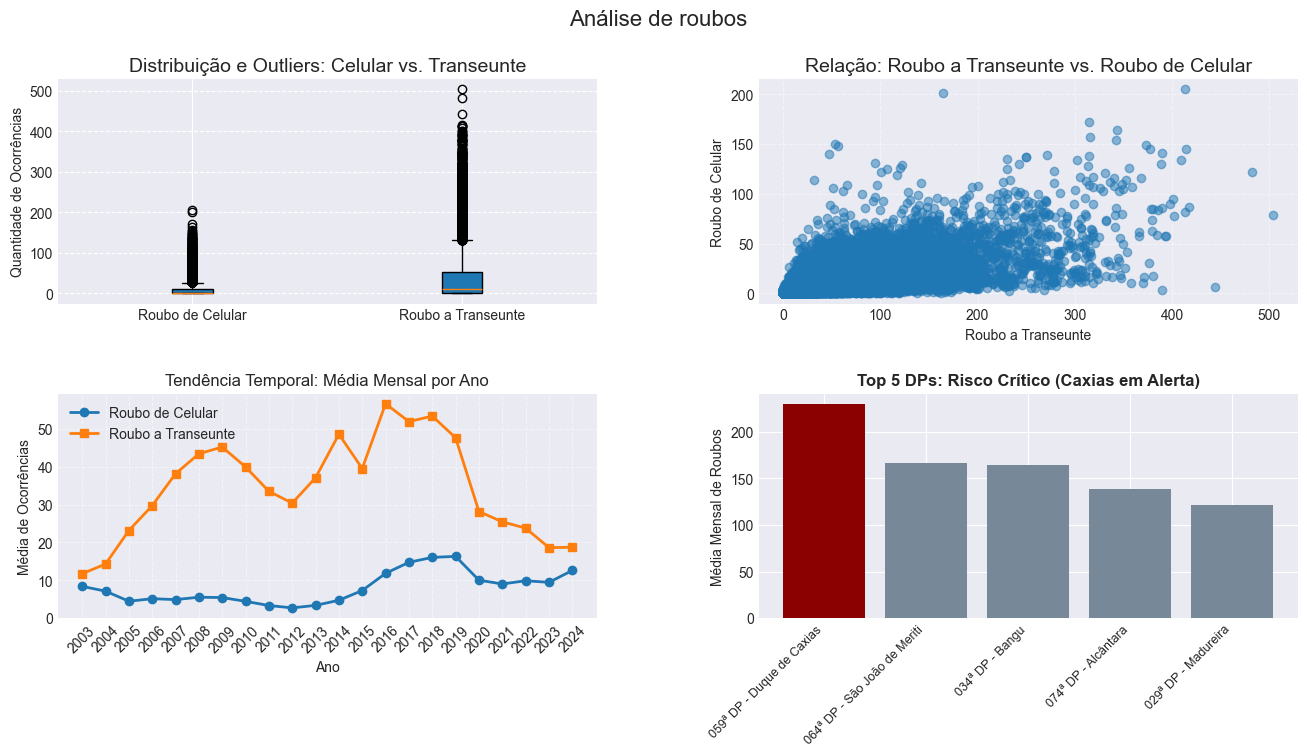

In [12]:
try: 

    plt.subplots(2, 2, figsize=(16, 7))
    plt.suptitle('Análise de roubos', fontsize=16)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.style.use('seaborn-v0_8-darkgrid')

    # primeiro quadrante -> Boxplot
    dados_grafico = [df_selecao['roubo_celular'], df_selecao['roubo_transeunte']]
    plt.subplot(2, 2, 1)
    plt.boxplot(dados_grafico, labels=['Roubo de Celular', 'Roubo a Transeunte'], patch_artist=True)
    plt.title('Distribuição e Outliers: Celular vs. Transeunte', fontsize=14)
    plt.ylabel('Quantidade de Ocorrências')
    plt.grid(axis='y', linestyle='--')

    # segundo quadrante -> Gráfico de Dispersão (Scatter Plot):
    plt.subplot(2, 2, 2)
    plt.scatter(df_selecao['roubo_transeunte'], df_selecao['roubo_celular'], alpha=0.5)
    plt.title('Relação: Roubo a Transeunte vs. Roubo de Celular', fontsize=14)
    plt.xlabel('Roubo a Transeunte')
    plt.ylabel('Roubo de Celular')
    plt.grid( linestyle='--', alpha=0.5)

    # terceiro quadrante -> Gráfico de Linha:
    plt.subplot(2, 2, 3)
    df_tendencia = df_selecao.groupby('ano')[['roubo_celular', 'roubo_transeunte']].mean().reset_index()
    plt.plot(df_tendencia['ano'], df_tendencia['roubo_celular'], marker='o', label='Roubo de Celular', linewidth=2)
    plt.plot(df_tendencia['ano'], df_tendencia['roubo_transeunte'], marker='s', label='Roubo a Transeunte', linewidth=2)
    plt.xticks(df_tendencia['ano'], rotation=45)
    plt.title('Tendência Temporal: Média Mensal por Ano', fontsize=12)
    plt.xlabel('Ano')
    plt.ylabel('Média de Ocorrências')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # quarto quadrante -> Gráfico de Barras:
    plt.subplot(2, 2, 4)
    top5_dps = df_selecao.groupby('nome')['roubo_transeunte'].mean().sort_values(ascending=False).head(5)
    cores_alerta = ['darkred', 'lightslategray', 'lightslategray', 'lightslategray', 'lightslategray']
    plt.bar(top5_dps.index, top5_dps.values, color=cores_alerta)
    plt.title('Top 5 DPs: Risco Crítico (Caxias em Alerta)', fontsize=12, weight='bold')
    plt.ylabel('Média Mensal de Roubos')
    plt.xticks(rotation=45, ha='right', fontsize=9)


except Exception as e: 
    print(f'Erro na vizualização de dados: {e}')

Perguntas (quadrante 2): 
- Existe uma correlação linear forte?
- R: É possível observar uma correlação linear através de um acumulo de pontos na diagonal, que mostra um tendência de aumento de roubos de celulares quando há aumento de roubos a transeuntes também, ou seja, provavlemnete eles ocorrem juntos em diversos casos. Porém é possível ver que o roubo a transeuntes se sobressai em relação aos roubos de celulares, pois a diagonal é mais deitada, com inlcinação maior em relação ao eixo x. 

- Quando o roubo a transeunte sobe, o roubo de celular sobe na
mesma proporção?
- R: Como dito na análise anterior, há uma tendência de aumento dos dois juntos, mas não na mesma proporção, o roubo a transeunte sobe mais que o celular, oque pode sugerir que é comum que em roubos a transeuntes se roube celular também, mas que também há muitos outros roubos a transeuntes que não são roubados celulares. 


Perguntas (quadrante 3):
- O risco está aumentando ou diminuindo com o passar do
tempo?
- R: Analisando os últimos 21 anos, dá para ver que o risco de roubos aumentou bastante, principalmente com picos em 2016 e 2018. Mesmo que tenha caído recentemente por causa da pandemia (com menos gente na rua), no geral a situação está mais perigosa hoje do que no começo dos dados. Isso mostra que o risco sobe e desce dependendo da situação do Rio. Por isso, a nossa empresa de seguros precisa ficar de olho para ajustar os preços sempre que a economia piorar ou o crime subir, garantindo que o valor que a gente recebe hoje seja o suficiente para pagar os roubos que podem aumentar logo ali na frente.

Pergunta (quadrante 4):
- Ordene as barras de forma decrescente para direcionamento
imediato da equipe de precificação.
- R: O gráfico mostra claramente quais são as 5 áreas mais perigosas para o nosso negócio. O recado principal para quem cuida dos preços é que a gente precisa cobrar mais caro de quem mora na região de Duque de Caxias (059ª DP) agora mesmo. O risco de roubo lá é muito maior do que em qualquer outro lugar do ranking. Para a nossa empresa não sair no prejuízo, o preço do seguro para quem vive nesse local precisa ser o mais alto da nossa lista, acompanhando essa gravidade que os dados mostraram.